<a href="https://colab.research.google.com/github/LampOfSocrates/reid/blob/main/EEEM071_CourseWork_3103.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Step 1: GPU Selection
1. Find "Edit" tab above, select "Hardware accelerator" and choose "GPU"
2. Run bellow command to check what GPU you got

In [4]:
from datetime import datetime

NOTEBOOK_START_TIME = datetime.now()

In [5]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


# Step 2: Code Preparation

We need to maintain our codebase with git history, so a file system (Google Drive) is needed
1. Select the left file icon and mount your Google Drive
2. Move path to Google Drive
3. Git clone code base


In [6]:
from pathlib import Path
import sys
import os

def is_colab() -> bool:
    try:
        import google.colab  # type: ignore
        return True
    except ImportError:
        return False

if is_colab():
  from google.colab import drive
  drive.mount('/content/drive')

  %cd /content
  !pip install -U --no-cache-dir gdown --pre

  # please download datasets from assignment doc link and upload, then unzip it.

  # Copy the uploaded zip from Google Drive into the Colab runtime, then unzip it locally.
  if not os.path.exists('/content/VeRi'):
      print('Unzipping VeRi dataset...')
      !cp "/content/drive/MyDrive/Colab Notebooks/data/VeRi.zip" /content/VeRi.zip
      !unzip /content/VeRi.zip -d /content/
  else:
      print('VeRi dataset already exists. Skipping unzip.')
  !ls -l /content

  # code
  if not os.path.exists('/content/reid'):
      print('Cloning repository...')
      !git clone https://github.com/LampOfSocrates/reid /content/reid
  else:
      print('Repository already exists. Pulling latest changes...')
      %cd /content/reid
      !git pull

  repo_root = Path('/content/reid')
  data_root = Path('/content/VeRi')

  # data

else:
    repo_root = Path.cwd()
    data_root = Path(r'G:\\My Drive\\VeRi')

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print(f'is_colab={is_colab()}')
print(f'repo_root={repo_root}')
print(f'data_root={data_root}')

Streaming output truncated to the last 5000 lines.
  inflating: /content/VeRi/image_train/0052_c014_00071235_0.jpg  
  inflating: /content/VeRi/image_train/0018_c016_00052300_0.jpg  
  inflating: /content/VeRi/image_train/0323_c002_00022890_0.jpg  
  inflating: /content/VeRi/image_train/0472_c003_00013625_0.jpg  
  inflating: /content/VeRi/image_train/0374_c012_00045475_0.jpg  
  inflating: /content/VeRi/image_train/0583_c019_00011690_0.jpg  
  inflating: /content/VeRi/image_train/0559_c013_00048385_0.jpg  
  inflating: /content/VeRi/image_train/0557_c014_00084660_0.jpg  
  inflating: /content/VeRi/image_train/0025_c003_00031930_0.jpg  
  inflating: /content/VeRi/image_train/0656_c002_00038705_0.jpg  
  inflating: /content/VeRi/image_train/0376_c006_00040385_1.jpg  
  inflating: /content/VeRi/image_train/0447_c013_00071570_0.jpg  
  inflating: /content/VeRi/image_train/0043_c004_00082075_0.jpg  
  inflating: /content/VeRi/image_train/0112_c006_00007820_0.jpg  
  inflating: /content/VeR

In [7]:
!pip install timm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 58.8 MB/s eta 0:00:00


In [8]:
# Code Area
%cd /content/reid

# Data Area
%ls -l /content/VeRi

#%ls -l /content/drive/MyDrive/reid

#!git clone https://github.com/Surrey-EEEM071-CVDL/EEEM071-Coursework-2025.git
#!git clone https://github.com/LampOfSocrates/reid.git

/content/reid
total 10592
-rwxr-xr-x 1 root root    1229 Mar  3  2025 camera_Dist.txt*
-rwxr-xr-x 1 root root      50 Mar  3  2025 camera_ID.txt*
-rwxr-xr-x 1 root root  541668 Mar  3  2025 gt_index.txt*
drwxr-xr-x 2 root root   81920 Mar  3  2025 image_query/
drwxr-xr-x 2 root root  552960 Mar  3  2025 image_test/
drwxr-xr-x 2 root root 1724416 Mar  3  2025 image_train/
-rwxr-xr-x 1 root root   61774 Mar  3  2025 jk_index.txt*
-rwxr-xr-x 1 root root      88 Mar  3  2025 list_color.txt*
-rwxr-xr-x 1 root root      77 Mar  3  2025 list_type.txt*
-rwxr-xr-x 1 root root   43628 Mar  3  2025 name_query.txt*
-rwxr-xr-x 1 root root  301054 Mar  3  2025 name_test.txt*
-rwxr-xr-x 1 root root  981396 Mar  3  2025 name_train.txt*
-rwxr-xr-x 1 root root    2738 Mar  3  2025 ReadMe.txt*
drwxr-xr-x 3 root root    4096 Mar  3  2025 samples/
-rwxr-xr-x 1 root root 1289288 Mar  3  2025 test_label.xml*
-rwxr-xr-x 1 root root  325853 Mar  3  2025 test_track.txt*
-rwxr-xr-x 1 root root  325853 Mar  3  20

# Step 3: Data Preparation

Because reading images from Google Drive is very slow, we download datasets to Colab temporary file
1. Install gdown
2. Download data
3. Unzip data with password

 Note that we have a folder called /content/drive/MyDrive/Veri with the full data

# Set Globals

In [9]:
from datetime import datetime
MAX_EPOCH = 3
DATA_FRACTION = 0.05
RUNTIME = datetime.now().strftime("%d%m_%H%M")


# Step 4: Training

# Section 1: Familiarity with the code provided (30 marks)

1. Run the code using the default settings. Discuss the training and evaluation
process (mention the loss functions used) followed by implications of the observed
performance using an appropriate metric. (10 marks)
2. Apply another CNN variant (that is not provided in the default settings). Critically
discuss and contrast the results with what observed in question 1 above. (10
marks)
3. Apply one more neural network architecture not from the same family as the above
questions. Critically discuss and contrast the results with what observed questions
1 and 2 above. (10 marks)

## Run default settings mobilenet_v3_small

In [10]:
%cd /content/reid

!STUDENT_ID='ss05548' STUDENT_NAME="Sourav Sen" python coursework/main.py \
-s veri \
-t veri \
-a mobilenet_v3_small \
--experiment mobilenet_v3_small \
--root /content/ \
--height 224 \
--width 224 \
--optim amsgrad \
--lr 0.0003 \
--max-epoch {MAX_EPOCH} \
--stepsize 20 40 \
--train-batch-size 64 \
--test-batch-size 100 \
--data-fraction {DATA_FRACTION} \
--train-sampler 'RandomIdentitySampler' \
--save-dir logs/{RUNTIME}/Q1/mobilenet_v3_small-veri


/content/reid
Student ID:ss05548
Student name:Sourav Sen
UUID:a1323091-8f8e-4e4f-ad20-15fce3d4f6ed
Experiment time:2026-04-01 12:24:19
Args:Namespace(root='/content/', source_names=['veri'], target_names=['veri'], workers=4, split_id=0, height=224, width=224, train_sampler='RandomIdentitySampler', data_fraction=0.05, random_erase=False, color_jitter=False, color_aug=False, crop_aug=False, blur_aug=False, optim='amsgrad', lr=0.0003, weight_decay=0.0005, momentum=0.9, sgd_dampening=0, sgd_nesterov=False, rmsprop_alpha=0.99, adam_beta1=0.9, adam_beta2=0.999, max_epoch=3, start_epoch=0, train_batch_size=64, test_batch_size=100, lr_scheduler='multi_step', stepsize=[20, 40], gamma=0.1, label_smooth=False, margin=0.3, num_instances=4, lambda_xent=1, lambda_htri=1, arch='mobilenet_v3_small', experiment='mobilenet_v3_small', no_pretrained=False, load_weights='', evaluate=False, eval_freq=-1, start_eval=0, test_size=800, query_remove=True, print_freq=10, seed=1, resume='', save_dir='logs/0104_12

## Run resnet50_fc512

In [11]:

!STUDENT_ID='ss05548' STUDENT_NAME="Sourav Sen" python coursework/main.py \
-s veri \
-t veri \
-a resnet50_fc512 \
--experiment resnet50_fc512 \
--root /content/ \
--height 224 \
--width 224 \
--optim amsgrad \
--lr 0.0003 \
--max-epoch {MAX_EPOCH} \
--stepsize 20 40 \
--train-batch-size 64 \
--test-batch-size 100 \
--data-fraction {DATA_FRACTION} \
--train-sampler 'RandomIdentitySampler' \
--save-dir logs/{RUNTIME}/Q1/resnet50_fc512-veri


Student ID:ss05548
Student name:Sourav Sen
UUID:d1924b1c-9bec-4a9f-96d3-6cafc8aa8691
Experiment time:2026-04-01 12:25:11
Args:Namespace(root='/content/', source_names=['veri'], target_names=['veri'], workers=4, split_id=0, height=224, width=224, train_sampler='RandomIdentitySampler', data_fraction=0.05, random_erase=False, color_jitter=False, color_aug=False, crop_aug=False, blur_aug=False, optim='amsgrad', lr=0.0003, weight_decay=0.0005, momentum=0.9, sgd_dampening=0, sgd_nesterov=False, rmsprop_alpha=0.99, adam_beta1=0.9, adam_beta2=0.999, max_epoch=3, start_epoch=0, train_batch_size=64, test_batch_size=100, lr_scheduler='multi_step', stepsize=[20, 40], gamma=0.1, label_smooth=False, margin=0.3, num_instances=4, lambda_xent=1, lambda_htri=1, arch='resnet50_fc512', experiment='resnet50_fc512', no_pretrained=False, load_weights='', evaluate=False, eval_freq=-1, start_eval=0, test_size=800, query_remove=True, print_freq=10, seed=1, resume='', save_dir='logs/0104_1224/Q1/resnet50_fc512-v

## Run vgg16

In [12]:

!STUDENT_ID='ss05548' STUDENT_NAME="Sourav Sen" python coursework/main.py \
-s veri \
-t veri \
-a vgg16 \
--experiment vgg16 \
--root /content/ \
--height 224 \
--width 224 \
--optim amsgrad \
--lr 0.0003 \
--max-epoch {MAX_EPOCH} \
--stepsize 20 40 \
--train-batch-size 64 \
--test-batch-size 100 \
--data-fraction {DATA_FRACTION} \
--train-sampler 'RandomIdentitySampler' \
--save-dir logs/{RUNTIME}/Q1/vgg16-veri


Student ID:ss05548
Student name:Sourav Sen
UUID:1430cb38-6cdc-499b-9bf4-e9ec39240167
Experiment time:2026-04-01 12:35:20
Args:Namespace(root='/content/', source_names=['veri'], target_names=['veri'], workers=4, split_id=0, height=224, width=224, train_sampler='RandomIdentitySampler', data_fraction=0.05, random_erase=False, color_jitter=False, color_aug=False, crop_aug=False, blur_aug=False, optim='amsgrad', lr=0.0003, weight_decay=0.0005, momentum=0.9, sgd_dampening=0, sgd_nesterov=False, rmsprop_alpha=0.99, adam_beta1=0.9, adam_beta2=0.999, max_epoch=3, start_epoch=0, train_batch_size=64, test_batch_size=100, lr_scheduler='multi_step', stepsize=[20, 40], gamma=0.1, label_smooth=False, margin=0.3, num_instances=4, lambda_xent=1, lambda_htri=1, arch='vgg16', experiment='vgg16', no_pretrained=False, load_weights='', evaluate=False, eval_freq=-1, start_eval=0, test_size=800, query_remove=True, print_freq=10, seed=1, resume='', save_dir='logs/0104_1224/Q1/vgg16-veri_20260401_123520', save_

## Run clip_senet

In [13]:

!STUDENT_ID='ss05548' STUDENT_NAME="Sourav Sen" python coursework/main.py \
-s veri \
-t veri \
-a clip_senet \
--experiment clip_senet \
--root /content/ \
--height 224 \
--width 224 \
--optim amsgrad \
--lr 0.0003 \
--max-epoch {MAX_EPOCH} \
--stepsize 20 40 \
--train-batch-size 64 \
--test-batch-size 100 \
--data-fraction {DATA_FRACTION} \
--train-sampler 'RandomIdentitySampler' \
--save-dir logs/{RUNTIME}/Q1/clip_senet-veri


Student ID:ss05548
Student name:Sourav Sen
UUID:fe5f0caa-bdd3-4d59-a552-426dbd669398
Experiment time:2026-04-01 12:52:34
Args:Namespace(root='/content/', source_names=['veri'], target_names=['veri'], workers=4, split_id=0, height=224, width=224, train_sampler='RandomIdentitySampler', data_fraction=0.05, random_erase=False, color_jitter=False, color_aug=False, crop_aug=False, blur_aug=False, optim='amsgrad', lr=0.0003, weight_decay=0.0005, momentum=0.9, sgd_dampening=0, sgd_nesterov=False, rmsprop_alpha=0.99, adam_beta1=0.9, adam_beta2=0.999, max_epoch=3, start_epoch=0, train_batch_size=64, test_batch_size=100, lr_scheduler='multi_step', stepsize=[20, 40], gamma=0.1, label_smooth=False, margin=0.3, num_instances=4, lambda_xent=1, lambda_htri=1, arch='clip_senet', experiment='clip_senet', no_pretrained=False, load_weights='', evaluate=False, eval_freq=-1, start_eval=0, test_size=800, query_remove=True, print_freq=10, seed=1, resume='', save_dir='logs/0104_1224/Q1/clip_senet-veri_20260401

## Compare Section 1 Runs

### Basic Table Section 1

In [14]:
from pathlib import Path
import json
import pandas as pd


def get_logs(runtime, question):
    if question not in {"Q1", "Q2"}:
        raise ValueError("question must be 'Q1' or 'Q2'")

    runs_root = Path("logs") / runtime / question
    rows = []

    for path in runs_root.rglob("comparison_summary.json"):
        print(path)
        with open(path, "r", encoding="utf-8") as f:
            data = json.load(f)

        rows.append({
            "arch": data.get("arch"),
            "experiment": data.get("experiment") or data.get("arch"),
            "run_dir": data.get("run_save_dir"),
            "timestamp": data.get("timestamp"),
            "lr": data.get("lr"),
            "train_batch_size": data.get("train_batch_size"),
            "test_batch_size": data.get("test_batch_size"),
            "data_fraction": data.get("data_fraction"),
            "best_rank1": data.get("best_rank1"),
            "best_mAP": data.get("best_mAP"),
            "final_rank1": (data.get("final_eval") or {}).get("rank1"),
            "final_mAP": (data.get("final_eval") or {}).get("mAP"),
            "total_elapsed_seconds": data.get("total_elapsed_seconds"),
            "avg_epoch_time_seconds": data.get("avg_epoch_time_seconds"),
        })

    return pd.DataFrame(rows)


df_q1 = get_logs(RUNTIME, "Q1")
display(df_q1)


logs/0104_1224/Q1/vgg16-veri_20260401_123520/comparison_summary.json
logs/0104_1224/Q1/clip_senet-veri_20260401_125234/comparison_summary.json
logs/0104_1224/Q1/resnet50_fc512-veri_20260401_122511/comparison_summary.json
logs/0104_1224/Q1/mobilenet_v3_small-veri_20260401_122419/comparison_summary.json


,arch,experiment,run_dir,timestamp,lr,train_batch_size,test_batch_size,data_fraction,best_rank1,best_mAP,final_rank1,final_mAP,total_elapsed_seconds,avg_epoch_time_seconds
0,vgg16,vgg16,logs/0104_1224/Q1/vgg16-veri_20260401_123520,20260401_123520,0.0003,64,100,0.05,0.012987,0.018332,0.012987,0.018332,1028.731249,332.467442
1,clip_senet,clip_senet,logs/0104_1224/Q1/clip_senet-veri_20260401_125234,20260401_125234,0.0003,64,100,0.05,0.142857,0.134964,0.142857,0.134964,99.105073,30.285163
2,resnet50_fc512,resnet50_fc512,logs/0104_1224/Q1/resnet50_fc512-veri_20260401...,20260401_122511,0.0003,64,100,0.05,0.285714,0.256586,0.285714,0.256586,604.845464,195.900786
3,mobilenet_v3_small,mobilenet_v3_small,logs/0104_1224/Q1/mobilenet_v3_small-veri_2026...,20260401_122419,0.0003,64,100,0.05,0.363636,0.259636,0.363636,0.259636,48.176079,14.975394


/tmp/ipykernel_613/2668935844.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='experiment', y='best_rank1', data=df_q1, ax=axes[0], palette='viridis')
/tmp/ipykernel_613/2668935844.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='experiment', y='best_mAP', data=df_q1, ax=axes[1], palette='magma')


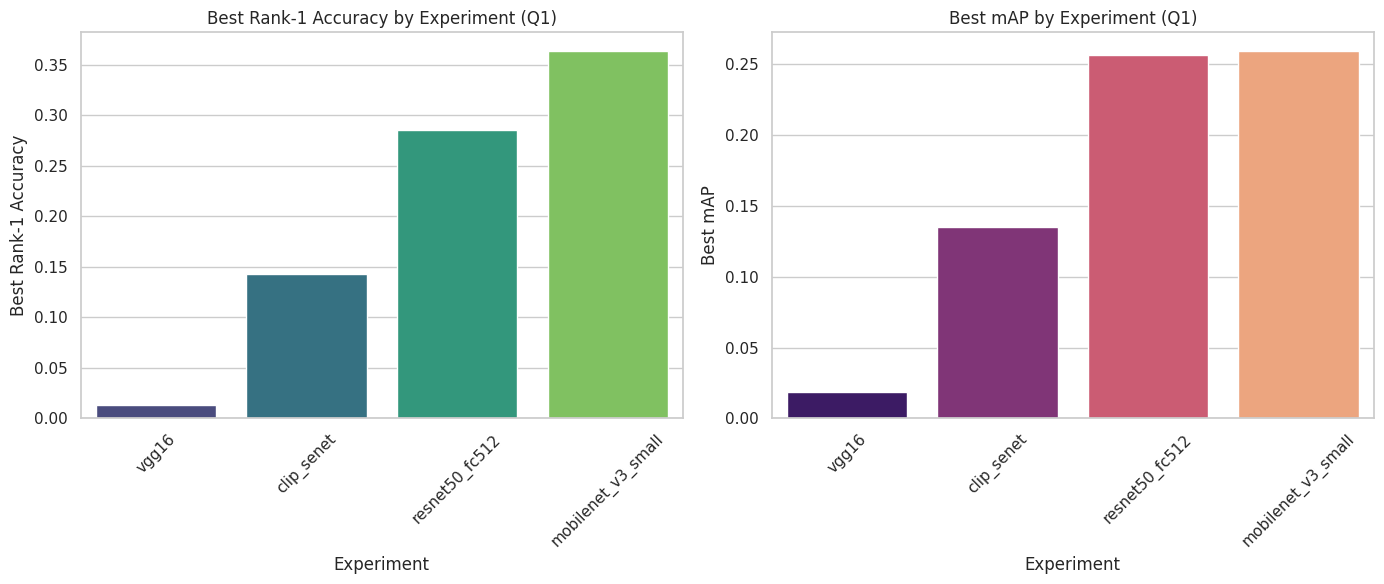

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_theme(style="whitegrid")

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot for best_rank1
sns.barplot(x='experiment', y='best_rank1', data=df_q1, ax=axes[0], palette='viridis')
axes[0].set_title('Best Rank-1 Accuracy by Experiment (Q1)')
axes[0].set_xlabel('Experiment')
axes[0].set_ylabel('Best Rank-1 Accuracy')
axes[0].tick_params(axis='x', rotation=45)

# Plot for best_mAP
sns.barplot(x='experiment', y='best_mAP', data=df_q1, ax=axes[1], palette='magma')
axes[1].set_title('Best mAP by Experiment (Q1)')
axes[1].set_xlabel('Experiment')
axes[1].set_ylabel('Best mAP')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


In [16]:
print('Performance Comparison:')
print('-----------------------')

resnet_perf = df_q1[df_q1['experiment'] == 'resnet50_fc512'][['experiment', 'best_rank1', 'best_mAP', 'total_elapsed_seconds']].iloc[0]
clip_perf = df_q1[df_q1['experiment'] == 'clip_senet'][['experiment', 'best_rank1', 'best_mAP', 'total_elapsed_seconds']].iloc[0]

print(f"Experiment: {resnet_perf['experiment']}")
print(f"  Best Rank-1: {resnet_perf['best_rank1']:.2f}")
print(f"  Best mAP: {resnet_perf['best_mAP']:.2f}")
print(f"  Total Elapsed Time: {resnet_perf['total_elapsed_seconds']:.2f} seconds\n")

print(f"Experiment: {clip_perf['experiment']}")
print(f"  Best Rank-1: {clip_perf['best_rank1']:.2f}")
print(f"  Best mAP: {clip_perf['best_mAP']:.2f}")
print(f"  Total Elapsed Time: {clip_perf['total_elapsed_seconds']:.2f} seconds")

print('\nAnalysis:')
if resnet_perf['best_rank1'] > clip_perf['best_rank1']:
    print(f"- resnet50_fc512 has a higher Rank-1 accuracy ({resnet_perf['best_rank1']:.2f}) than clip_senet ({clip_perf['best_rank1']:.2f}).")
else:
    print(f"- clip_senet has a higher Rank-1 accuracy ({clip_perf['best_rank1']:.2f}) than resnet50_fc512 ({resnet_perf['best_rank1']:.2f}).")

if resnet_perf['best_mAP'] > clip_perf['best_mAP']:
    print(f"- resnet50_fc512 has a higher mAP ({resnet_perf['best_mAP']:.2f}) than clip_senet ({clip_perf['best_mAP']:.2f}).")
else:
    print(f"- clip_senet has a higher mAP ({clip_perf['best_mAP']:.2f}) than resnet50_fc512 ({resnet_perf['best_mAP']:.2f}).")

if resnet_perf['total_elapsed_seconds'] < clip_perf['total_elapsed_seconds']:
    print(f"- resnet50_fc512 trained faster ({resnet_perf['total_elapsed_seconds']:.2f}s) than clip_senet ({clip_perf['total_elapsed_seconds']:.2f}s).")
else:
    print(f"- clip_senet trained faster ({clip_perf['total_elapsed_seconds']:.2f}s) than resnet50_fc512 ({resnet_perf['total_elapsed_seconds']:.2f}s).")


Performance Comparison:
-----------------------
Experiment: resnet50_fc512
  Best Rank-1: 0.29
  Best mAP: 0.26
  Total Elapsed Time: 604.85 seconds

Experiment: clip_senet
  Best Rank-1: 0.14
  Best mAP: 0.13
  Total Elapsed Time: 99.11 seconds

Analysis:
- resnet50_fc512 has a higher Rank-1 accuracy (0.29) than clip_senet (0.14).
- resnet50_fc512 has a higher mAP (0.26) than clip_senet (0.13).
- clip_senet trained faster (99.11s) than resnet50_fc512 (604.85s).


### Parse Logs for Epoch stats

In [17]:
import json
import re
import pandas as pd
from pathlib import Path

def parse_epoch_logs(log_text, experiment_name):
    epochs_data = []
    pattern = r"Epoch\s+(\d+)/\d+.*?acc=([\d.]+).*?htri=([\d.]+).*?xent=([\d.]+)"

    for line in log_text.splitlines():
        match = re.search(pattern, line)
        if match:
            epochs_data.append({
                'experiment': experiment_name,
                'epoch': int(match.group(1)),
                'acc': float(match.group(2)),
                'htri': float(match.group(3)),
                'xent': float(match.group(4))
            })
    return epochs_data

def get_all_epoch_data(runtime_dir='3103_2306', question='Q1'):
    all_data = []
    log_root = Path('logs') / runtime_dir / question
    print(f"Parsing logs from {log_root}")

    for summary_path in log_root.rglob('comparison_summary.json'):
        print(summary_path)
        with open(summary_path, 'r', encoding='utf-8') as f:
            summary = json.load(f)

        experiment = summary.get('experiment') or summary.get('arch')
        log_path = Path(summary.get('run_save_dir', summary_path.parent)) / 'log_train.txt'
        if not log_path.exists():
            log_path = summary_path.parent / 'log_train.txt'
        if not log_path.exists():
            continue

        with open(log_path, 'r', encoding='utf-8') as f:
            all_data.extend(parse_epoch_logs(f.read(), experiment))

    return pd.DataFrame(all_data)


all_epochs_df = get_all_epoch_data(RUNTIME)
display(all_epochs_df)


Parsing logs from logs/0104_1224/Q1
logs/0104_1224/Q1/vgg16-veri_20260401_123520/comparison_summary.json
logs/0104_1224/Q1/clip_senet-veri_20260401_125234/comparison_summary.json
logs/0104_1224/Q1/resnet50_fc512-veri_20260401_122511/comparison_summary.json
logs/0104_1224/Q1/mobilenet_v3_small-veri_20260401_122419/comparison_summary.json


,experiment,epoch,acc,htri,xent
0,vgg16,1,0.00,5.6631,6.4098
1,vgg16,1,0.00,5.6631,6.4098
2,vgg16,1,0.00,5.6631,6.4098
3,vgg16,1,0.00,5.6631,6.4098
4,vgg16,1,0.00,5.6631,6.4098
...,...,...,...,...,...
403,mobilenet_v3_small,3,1.30,0.7820,6.2537
404,mobilenet_v3_small,3,1.30,0.7820,6.2537
405,mobilenet_v3_small,3,1.52,0.7694,6.2557
406,mobilenet_v3_small,3,1.52,0.7694,6.2557


### Per Epoch Plots

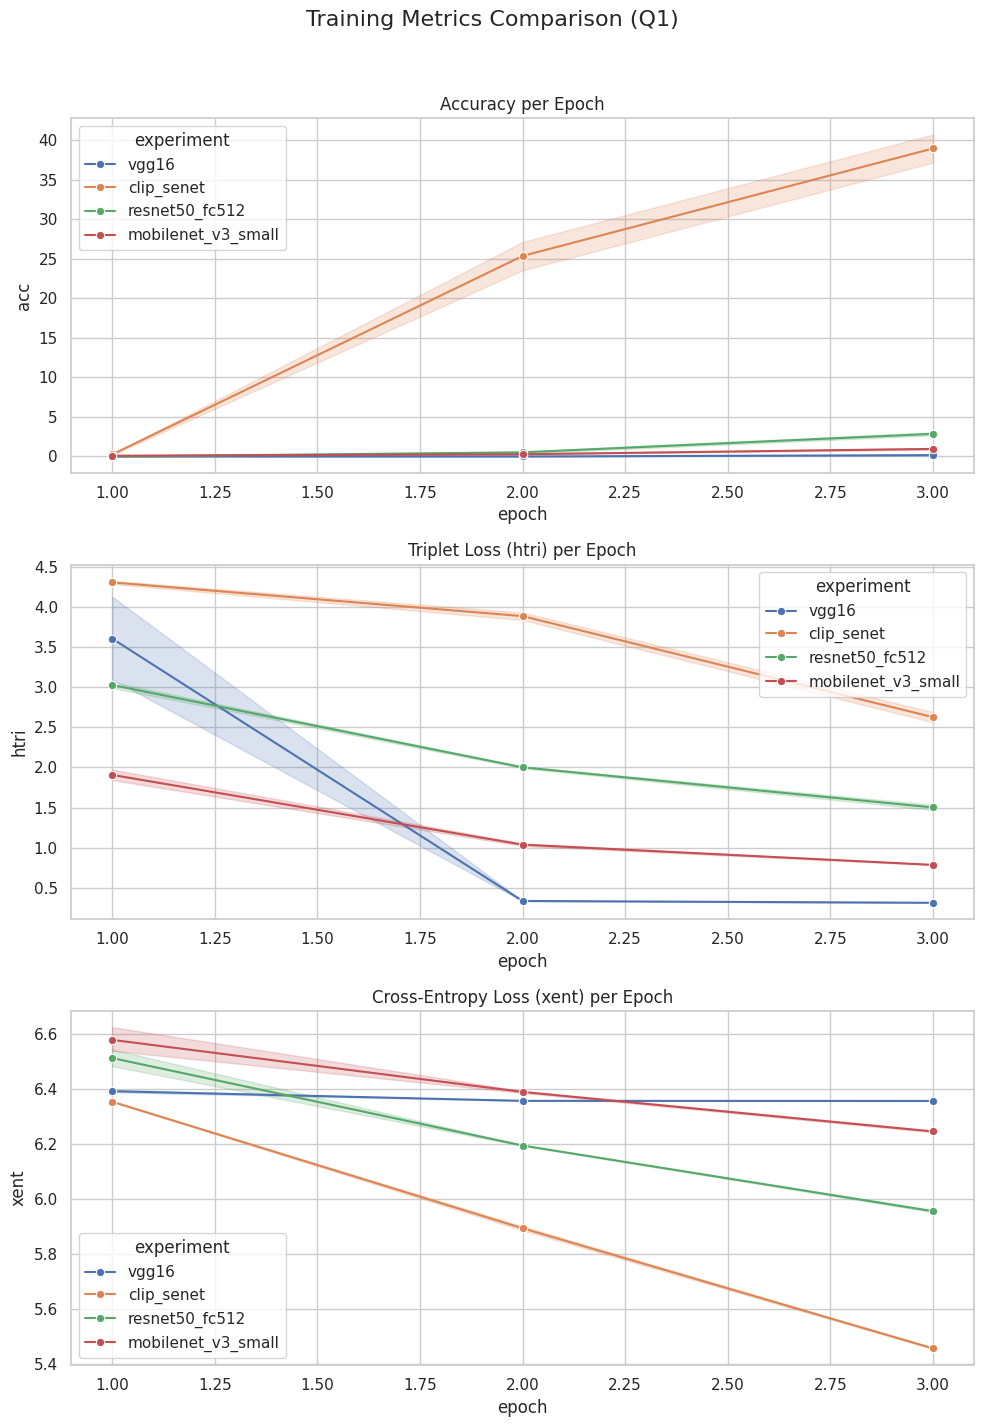

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(3, 1, figsize=(10, 15), sharex=False)
fig.suptitle('Training Metrics Comparison (Q1)', fontsize=16)

# Accuracy
sns.lineplot(data=all_epochs_df, x='epoch', y='acc', hue='experiment', marker='o', ax=axes[0])
axes[0].set_title('Accuracy per Epoch')

# Triplet Loss
sns.lineplot(data=all_epochs_df, x='epoch', y='htri', hue='experiment', marker='o', ax=axes[1])
axes[1].set_title('Triplet Loss (htri) per Epoch')

# Cross-Entropy Loss
sns.lineplot(data=all_epochs_df, x='epoch', y='xent', hue='experiment', marker='o', ax=axes[2])
axes[2].set_title('Cross-Entropy Loss (xent) per Epoch')

plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()


Comparison of Learning Efficiency:


,Experiment,Loss Reduction (%),Absolute Acc Gain
0,vgg16,0.803457,0.16
1,clip_senet,14.359192,29.77
2,resnet50_fc512,7.411739,2.43
3,mobilenet_v3_small,2.795388,1.36


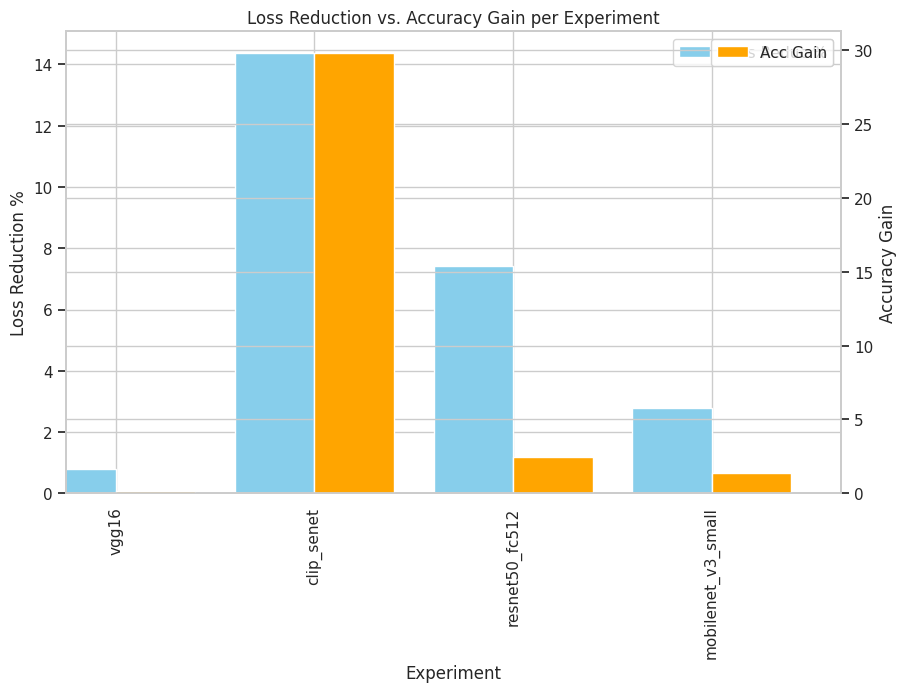

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# Calculate the percentage reduction in loss and increase in accuracy from Epoch 1 to Final Epoch
analysis = []
for experiment in all_epochs_df['experiment'].unique():
    subset = all_epochs_df[all_epochs_df['experiment'] == experiment].sort_values('epoch')
    first = subset.iloc[0]
    last = subset.iloc[-1]

    loss_reduction = ((first['xent'] - last['xent']) / first['xent']) * 100
    acc_improvement = last['acc'] - first['acc']

    analysis.append({
        'Experiment': experiment,
        'Loss Reduction (%)': loss_reduction,
        'Absolute Acc Gain': acc_improvement
    })

df_analysis = pd.DataFrame(analysis)
print("Comparison of Learning Efficiency:")
display(df_analysis)

# Plotting the disconnect
fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()

df_analysis.plot(x='Experiment', y='Loss Reduction (%)', kind='bar', ax=ax1, position=1, width=0.4, color='skyblue', label='Loss Reduc %')
df_analysis.plot(x='Experiment', y='Absolute Acc Gain', kind='bar', ax=ax2, position=0, width=0.4, color='orange', label='Acc Gain')

ax1.set_ylabel('Loss Reduction %')
ax2.set_ylabel('Accuracy Gain')
plt.title('Loss Reduction vs. Accuracy Gain per Experiment')
plt.show()


# Section 2: Dataset preparation and augmentation experiment (25 marks)

Begin with the default data augmentation setting with random, horizontal flip and
Random2DTranslation.
1. Further append on top two additional data augmentation techniques, one at a time
e.g., Default + “crop”, Default + “horizontal flip”, and Default + “blurring”. Compare
the results with the default configuration in the provided code and discuss the
differences in performance. (20 marks)
2. Combine the augmentation techniques from Question 1 to find the best-performing
combination. Highlight any improvement or drop in the overall score. (5 marks)

## Run Crop Clip Senet

In [20]:

!STUDENT_ID='ss05548' STUDENT_NAME="Sourav Sen" python coursework/main.py \
-s veri \
-t veri \
-a clip_senet \
--experiment clip_senet_crop \
--root /content/ \
--height 224 \
--width 224 \
--optim amsgrad \
--lr 0.0003 \
--max-epoch {MAX_EPOCH} \
--stepsize 20 40 \
--train-batch-size 64 \
--test-batch-size 100 \
--data-fraction {DATA_FRACTION} \
--train-sampler 'RandomIdentitySampler' \
--crop-aug \
--save-dir logs/{RUNTIME}/Q2/clip_senet_crop


Student ID:ss05548
Student name:Sourav Sen
UUID:12a7eec1-ab13-41ae-9bca-373897cdf1b2
Experiment time:2026-04-01 12:54:29
Args:Namespace(root='/content/', source_names=['veri'], target_names=['veri'], workers=4, split_id=0, height=224, width=224, train_sampler='RandomIdentitySampler', data_fraction=0.05, random_erase=False, color_jitter=False, color_aug=False, crop_aug=True, blur_aug=False, optim='amsgrad', lr=0.0003, weight_decay=0.0005, momentum=0.9, sgd_dampening=0, sgd_nesterov=False, rmsprop_alpha=0.99, adam_beta1=0.9, adam_beta2=0.999, max_epoch=3, start_epoch=0, train_batch_size=64, test_batch_size=100, lr_scheduler='multi_step', stepsize=[20, 40], gamma=0.1, label_smooth=False, margin=0.3, num_instances=4, lambda_xent=1, lambda_htri=1, arch='clip_senet', experiment='clip_senet_crop', no_pretrained=False, load_weights='', evaluate=False, eval_freq=-1, start_eval=0, test_size=800, query_remove=True, print_freq=10, seed=1, resume='', save_dir='logs/0104_1224/Q2/clip_senet_crop_2026

## Run Blur Clip Senet

In [21]:


!STUDENT_ID='ss05548' STUDENT_NAME="Sourav Sen" python coursework/main.py \
-s veri \
-t veri \
-a clip_senet \
--experiment clip_senet_blur \
--root /content/ \
--height 224 \
--width 224 \
--optim amsgrad \
--lr 0.0003 \
--max-epoch {MAX_EPOCH} \
--stepsize 20 40 \
--train-batch-size 64 \
--test-batch-size 100 \
--data-fraction {DATA_FRACTION} \
--train-sampler 'RandomIdentitySampler' \
--blur-aug \
--save-dir logs/{RUNTIME}/Q2/clip_senet_blur


Student ID:ss05548
Student name:Sourav Sen
UUID:3f9c6935-0b91-45b1-81b7-673afa464c75
Experiment time:2026-04-01 12:56:08
Args:Namespace(root='/content/', source_names=['veri'], target_names=['veri'], workers=4, split_id=0, height=224, width=224, train_sampler='RandomIdentitySampler', data_fraction=0.05, random_erase=False, color_jitter=False, color_aug=False, crop_aug=False, blur_aug=True, optim='amsgrad', lr=0.0003, weight_decay=0.0005, momentum=0.9, sgd_dampening=0, sgd_nesterov=False, rmsprop_alpha=0.99, adam_beta1=0.9, adam_beta2=0.999, max_epoch=3, start_epoch=0, train_batch_size=64, test_batch_size=100, lr_scheduler='multi_step', stepsize=[20, 40], gamma=0.1, label_smooth=False, margin=0.3, num_instances=4, lambda_xent=1, lambda_htri=1, arch='clip_senet', experiment='clip_senet_blur', no_pretrained=False, load_weights='', evaluate=False, eval_freq=-1, start_eval=0, test_size=800, query_remove=True, print_freq=10, seed=1, resume='', save_dir='logs/0104_1224/Q2/clip_senet_blur_2026

## Compare Section 2 Runs


### Basic Table Section 2

In [22]:
experiment_to_filter = 'clip_senet'

df_q1_all = get_logs(RUNTIME, "Q1")
df_q1_filtered = df_q1_all[df_q1_all['experiment'] == experiment_to_filter]
display(df_q1_filtered)

df_q2 = get_logs(RUNTIME, "Q2")
df_comparison = pd.concat([df_q1_filtered, df_q2], ignore_index=True)
display(df_comparison)


logs/0104_1224/Q1/vgg16-veri_20260401_123520/comparison_summary.json
logs/0104_1224/Q1/clip_senet-veri_20260401_125234/comparison_summary.json
logs/0104_1224/Q1/resnet50_fc512-veri_20260401_122511/comparison_summary.json
logs/0104_1224/Q1/mobilenet_v3_small-veri_20260401_122419/comparison_summary.json


,arch,experiment,run_dir,timestamp,lr,train_batch_size,test_batch_size,data_fraction,best_rank1,best_mAP,final_rank1,final_mAP,total_elapsed_seconds,avg_epoch_time_seconds
1,clip_senet,clip_senet,logs/0104_1224/Q1/clip_senet-veri_20260401_125234,20260401_125234,0.0003,64,100,0.05,0.142857,0.134964,0.142857,0.134964,99.105073,30.285163


logs/0104_1224/Q2/clip_senet_crop_20260401_125429/comparison_summary.json
logs/0104_1224/Q2/clip_senet_blur_20260401_125608/comparison_summary.json


,arch,experiment,run_dir,timestamp,lr,train_batch_size,test_batch_size,data_fraction,best_rank1,best_mAP,final_rank1,final_mAP,total_elapsed_seconds,avg_epoch_time_seconds
0,clip_senet,clip_senet,logs/0104_1224/Q1/clip_senet-veri_20260401_125234,20260401_125234,0.0003,64,100,0.05,0.142857,0.134964,0.142857,0.134964,99.105073,30.285163
1,clip_senet,clip_senet_crop,logs/0104_1224/Q2/clip_senet_crop_20260401_125429,20260401_125429,0.0003,64,100,0.05,0.155844,0.133736,0.155844,0.133736,94.173309,28.651416
2,clip_senet,clip_senet_blur,logs/0104_1224/Q2/clip_senet_blur_20260401_125608,20260401_125608,0.0003,64,100,0.05,0.155844,0.142294,0.155844,0.142294,99.357775,30.347329


In [23]:
# Extract Q2 augmentation data
df_q2_epochs = get_all_epoch_data(RUNTIME, question='Q2')
df_q2_crop = df_q2_epochs[df_q2_epochs['experiment'] == 'clip_senet_crop'].copy()
df_q2_blur = df_q2_epochs[df_q2_epochs['experiment'] == 'clip_senet_blur'].copy()

# Get Q1 baseline for comparison
df_baseline = all_epochs_df[all_epochs_df['experiment'] == 'clip_senet'].copy()

# Combine for plotting
df_aug_comp = pd.concat([df_baseline, df_q2_crop, df_q2_blur], ignore_index=True)
display(df_aug_comp)


Parsing logs from logs/0104_1224/Q2
logs/0104_1224/Q2/clip_senet_crop_20260401_125429/comparison_summary.json
logs/0104_1224/Q2/clip_senet_blur_20260401_125608/comparison_summary.json


,experiment,epoch,acc,htri,xent
0,clip_senet,1,0.00,4.2510,6.3576
1,clip_senet,1,0.00,4.2510,6.3576
2,clip_senet,1,0.00,4.2510,6.3576
3,clip_senet,1,0.00,4.2510,6.3576
4,clip_senet,1,0.00,4.2510,6.3576
...,...,...,...,...,...
301,clip_senet_blur,3,31.61,2.5357,5.4419
302,clip_senet_blur,3,31.61,2.5357,5.4419
303,clip_senet_blur,3,27.88,2.4157,5.4379
304,clip_senet_blur,3,27.88,2.4157,5.4379


### Comparision Plots Section 2 : Augmentation Experiment


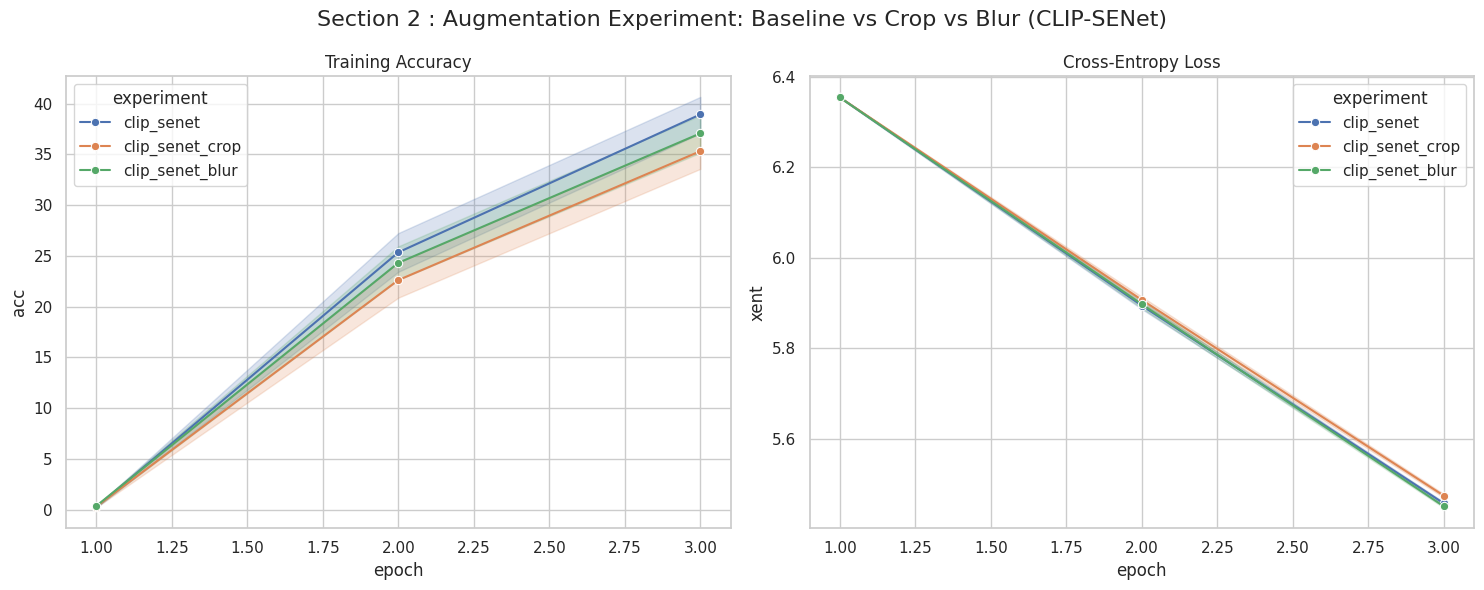

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Section 2 : Augmentation Experiment: Baseline vs Crop vs Blur (CLIP-SENet)', fontsize=16)

# Accuracy Comparison
sns.lineplot(data=df_aug_comp, x='epoch', y='acc', hue='experiment', marker='o', ax=axes[0])
axes[0].set_title('Training Accuracy')

# Loss Comparison (xent)
sns.lineplot(data=df_aug_comp, x='epoch', y='xent', hue='experiment', marker='o', ax=axes[1])
axes[1].set_title('Cross-Entropy Loss')

plt.tight_layout()
plt.show()


# Section 3: Exploration of Hyperparameters (25 marks)

Start with the default learning rate (LR) and batch size (BS).
1. Exploration of Learning Rate (LR). (10 marks)
a. Experiment with 4 values of LR (in addition to the default value).
b. Discuss the observed impact of each value on overall performance.
2. Exploration Batch sizes. (10 marks)
a. Fixing the best LR value from the experiments in question 1
above, test 4 different values of the BS in addition to the default
value.
b. Discuss the impact observed on overall performance.
3. Exploration of the optimizer. (5 marks)
3. Fixing the best Learning Rate value and best Batch Size value from the
experiments in Questions 1 and 2, respectively, test with changing the
optimizer to SGD, using PyTorch’s internal class.
a. Discuss the impact observed on overall performance

In [27]:
import os
STUDENT_ID = "ss05548"
STUDENT_NAME = "Sourav Sen"
RUNTIME = datetime.now().strftime("%Y%m%d_%H%M%S")

PROJECT_ROOT = Path.cwd()
COURSEWORK_DIR = PROJECT_ROOT / "coursework"
MAIN_PY = COURSEWORK_DIR / "main.py"

BASE_ARGS = {
    "source": "veri",
    "target": "veri",
    "arch": "clip_senet",
    "root": "/content/",
    "height": 224,
    "width": 224,
    "optim": "amsgrad",
    "lr": 0.0003,
    "max_epoch": MAX_EPOCH,
    "stepsize": [20, 40],
    "train_batch_size": 64,
    "test_batch_size": 100,
    "data_fraction": DATA_FRACTION,
    "train_sampler": "RandomIdentitySampler",
    "blur_aug": True,
}

LR_VALUES = [0.0001, 0.0003, 0.001, 0.005, 0.01]
BATCH_SIZES = [8, 16, 32, 64, 128]

print(f"Runtime folder: {RUNTIME}")
print(f"Using coursework entry point: {MAIN_PY}")

def format_value(value):
    if isinstance(value, float):
        return format(value, ".10g").replace(".", "p")
    return str(value)

def experiment_name(params, keys):
    parts = [BASE_ARGS["arch"]]
    for key in keys:
        parts.append(f"{key}_{format_value(params[key])}")
    return "_".join(parts)

def build_save_dir(params, keys):
    return f"logs/{RUNTIME}/Q3/{experiment_name(params, keys)}"

def build_command(params, save_dir, experiment):
    command = [
        "python",
        str(MAIN_PY),
        "-s",
        params["source"],
        "-t",
        params["target"],
        "-a",
        params["arch"],
        "--experiment",
        experiment,
        "--root",
        params["root"],
        "--height",
        str(params["height"]),
        "--width",
        str(params["width"]),
        "--optim",
        params["optim"],
        "--lr",
        str(params["lr"]),
        "--max-epoch",
        str(params["max_epoch"]),
        "--stepsize",
        *[str(step) for step in params["stepsize"]],
        "--train-batch-size",
        str(params["train_batch_size"]),
        "--test-batch-size",
        str(params["test_batch_size"]),
        "--data-fraction",
        str(params["data_fraction"]),
        "--train-sampler",
        params["train_sampler"],
        "--save-dir",
        save_dir,
    ]

    return command


def run_experiment(params, keys):
    experiment = experiment_name(params, keys)
    save_dir = build_save_dir(params, keys)
    command = build_command(params, save_dir, experiment)

    env = os.environ.copy()
    env["STUDENT_ID"] = STUDENT_ID
    env["STUDENT_NAME"] = STUDENT_NAME

    #print("Running:", " \".join(command))
    print("Experiment:", experiment)
    print("Save dir:", save_dir)
    print(command)
    #subprocess.run(command, cwd=PROJECT_ROOT, env=env, check=True)

def run_lr_sweep():
    for lr in LR_VALUES:
        params = dict(BASE_ARGS)
        params["lr"] = lr
        run_experiment(params, keys=["optim", "lr", "train_batch_size"])

def run_batch_size_sweep(best_lr):
    for batch_size in BATCH_SIZES:
        params = dict(BASE_ARGS)
        params["lr"] = best_lr
        params["train_batch_size"] = batch_size
        run_experiment(params, keys=["optim", "lr", "train_batch_size"])

run_lr_sweep()
#run_batch_size_sweep()


Runtime folder: 20260401_140420
Using coursework entry point: /content/reid/coursework/main.py
Experiment: clip_senet_optim_amsgrad_lr_0p0001_train_batch_size_64
Save dir: logs/20260401_140420/Q3/clip_senet_optim_amsgrad_lr_0p0001_train_batch_size_64
['python', '/content/reid/coursework/main.py', '-s', 'veri', '-t', 'veri', '-a', 'clip_senet', '--experiment', 'clip_senet_optim_amsgrad_lr_0p0001_train_batch_size_64', '--root', '/content/', '--height', '224', '--width', '224', '--optim', 'amsgrad', '--lr', '0.0001', '--max-epoch', '3', '--stepsize', '20', '40', '--train-batch-size', '64', '--test-batch-size', '100', '--data-fraction', '0.05', '--train-sampler', 'RandomIdentitySampler', '--save-dir', 'logs/20260401_140420/Q3/clip_senet_optim_amsgrad_lr_0p0001_train_batch_size_64']
Experiment: clip_senet_optim_amsgrad_lr_0p0003_train_batch_size_64
Save dir: logs/20260401_140420/Q3/clip_senet_optim_amsgrad_lr_0p0003_train_batch_size_64
['python', '/content/reid/coursework/main.py', '-s', 'v

In [28]:
NOTEBOOK_END_TIME = datetime.now()
NOTEBOOK_RUNTIME = (NOTEBOOK_END_TIME - NOTEBOOK_START_TIME).total_seconds()
print(f"Notebook Run time: {NOTEBOOK_RUNTIME:.2f} seconds")

Notebook Run time: 6113.52 seconds
